#  Basics of Image analysis and rendering & Image processing



---

# Table of Contents

## 1. Basics of Image Analysis and Rendering
- [1.1 Digital Image: Definition and Types](#11-define-the-general-concept-of-digital-image-and-explain-its-types)
- [1.2 Color Spaces](#12-define-the-concept-of-color-spaces-and-mention-some)
- [1.3 Gray-scale Codification](#13-explain-the-gray-scale-codification)
- [1.4 General Workflow of Image Analysis](#14-define-and-explain-the-general-workflow-of-the-overall-image-analysis-process)
- [1.5 Levels of Image Processing](#15-define-and-explain-the-three-levels-of-image-processinganalysis)
- [1.6 Rendering and the Rendering Pipeline](#16-define-rendering-and-explain-its-significance-in-computer-graphics-and-discuss-the-rendering-pipeline-and-its-stages)
- [1.7 Real-time vs Offline Rendering](#17-describe-the-difference-between-real-time-rendering-and-offline-rendering)
- [1.8 Rasterization](#18-explain-the-concept-of-rasterization-and-its-role-in-rendering)

## 2. Image Processing: Transformation and Filtering
- [2.1 Linear Transformations: Brightness and Contrast](#21-linear-transformations-brightness-adjustment-and-contrast-stretching)
- [2.2 Basic Image Filtering: Mean and Gaussian](#22-basic-image-filtering-mean-and-gaussian-filtering)
- [2.3 Global Thresholding](#23-global-thresholding)
- [2.4 Edge Detection: Sobel and Prewitt](#24-edge-detection-sobel-and-prewitt-operators)
- [2.5 Histogram Equalization](#25-histogram-equalization)
- [2.6 2D Convolution Operation](#26-2d-convolution-operation)

---

### 1.1 Define the general concept of digital image and explain its types.

A **digital image** is a two-dimensional representation of a visual object, stored in a computer as a grid of **pixels**. Each pixel has color or intensity information.

**Types of digital images:**

* **Binary images**: Only black and white pixels (0 or 1).
* **Grayscale images**: Shades of gray, where each pixel has an intensity value (usually from 0 to 255).
* **Color images**: Each pixel has values for multiple color channels (commonly RGB – Red, Green, Blue).
* **Multispectral/Hyperspectral images**: Contain data from many wavelengths (used in remote sensing, medical imaging).

---

### 1.2 Define the concept of color spaces and mention some.

A **color space** is a method of representing colors in a consistent way using coordinate systems.

**Common color spaces include:**

* **RGB (Red, Green, Blue)** – used in screens and digital imaging.
* **HSV (Hue, Saturation, Value)** – useful for color filtering and adjustments.
* **CMYK (Cyan, Magenta, Yellow, Key/Black)** – used in printing.
* **Lab** – based on human vision, separates lightness and color.

---

### 1.3 Explain the gray-scale codification.

**Gray-scale codification** represents an image using shades of gray only, without color. Each pixel is assigned a single intensity value, usually from **0 (black)** to **255 (white)** in 8-bit images. It reduces memory usage and simplifies image processing tasks like edge detection and thresholding.

---

### 1.4 Define and explain the general workflow of the overall image analysis process.

The **general workflow of image analysis** includes:

1. **Acquisition**: Capture or load the image.
2. **Preprocessing**: Clean the image (e.g., remove noise, adjust brightness).
3. **Segmentation**: Divide the image into meaningful regions (e.g., separate objects).
4. **Feature Extraction**: Identify patterns or shapes (edges, textures, corners).
5. **Classification/Analysis**: Use extracted features to interpret or label parts of the image.
6. **Post-processing/Visualization**: Display or use the results for further tasks.

---

### 1.5 Define and explain the three levels of image processing/analysis.

1. **Low-level processing**: Basic operations like noise removal, contrast adjustment, edge detection. Input and output are both images.
2. **Mid-level processing**: Tasks like segmentation, shape detection, or object tracking. Input is an image, output is information (e.g., object boundaries).
3. **High-level processing**: Interpretation and understanding, such as object recognition or scene analysis. Output is a description or decision.

---

### 1.6 Define rendering and explain its significance in computer graphics, and discuss the rendering pipeline and its stages.

**Rendering** is the process of generating a final image from a 3D model using lighting, textures, and camera angles. It's essential in computer graphics to visualize virtual scenes in games, simulations, movies, etc.

**Rendering pipeline stages:**

1. **Modeling**: Define 3D shapes and objects.
2. **Transformation**: Convert objects into camera view (world and view transformations).
3. **Lighting**: Calculate how light affects surfaces.
4. **Projection**: Convert 3D scene to 2D image (camera perspective).
5. **Rasterization**: Turn projected shapes into pixels.
6. **Shading and Texturing**: Add colors, textures, and shadows to pixels.
7. **Display**: Show the final image on screen.

---

### 1.7 Describe the difference between real-time rendering and offline rendering.

* **Real-time rendering**: Images are generated quickly (e.g., 30–60 frames per second) for interactive applications like video games or VR. Focus is on speed and responsiveness.
* **Offline rendering**: Takes longer but produces high-quality, photorealistic images. Used in movies and animations. Quality is prioritized over speed.

---

### 1.8 Explain the concept of rasterization and its role in rendering.

**Rasterization** is the process of converting 3D shapes (like triangles) into pixels on a 2D screen. It determines **which pixels** a shape covers and assigns them colors based on textures, lighting, and shading. Rasterization is a **key step** in rendering, especially in real-time graphics, because it's fast and hardware-accelerated by GPUs.

---

# Image Processing: Transformation and Filtering

This notebook demonstrates fundamental image processing techniques using OpenCV and NumPy. Image processing involves manipulating digital images to enhance, analyze, or extract useful information from them. These techniques form the foundation of computer vision and are essential for tasks ranging from medical imaging to autonomous vehicles.

We will explore the following questions:

1. How can we implement linear transformations such as brightness adjustment and contrast stretching?
2. What are the steps to apply basic image filtering techniques like mean filtering and Gaussian filtering?
3. How can we perform global thresholding on an image?
4. How do we detect edges in an image using Sobel or Prewitt operators?
5. What is histogram equalization, and how can it be implemented?
6. How can we perform a 2D convolution operation using a predefined kernel?

## 1. Load the Image

In this section, we load the image using OpenCV (cv2). The image is read in BGR format (the default for OpenCV) and then converted to RGB for proper visualization with Matplotlib. This step is crucial as it sets up our input data for all subsequent processing operations.

We will use the image `test.jpg` from the `data` folder depicting a business man on serious business.

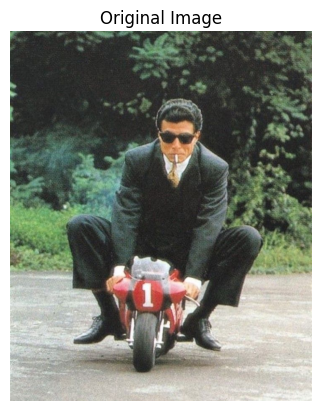

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'data/test.jpg'
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f'Image not found at {image_path}')

# Convert to RGB for visualization
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the original image
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

## 2.1 Linear Transformations: Brightness Adjustment and Contrast Stretching

Linear transformations are fundamental image processing operations that modify pixel values using mathematical functions. Here we implement:

- **Brightness Adjustment**: Adds a constant value (beta=50) to all pixels, effectively shifting the entire intensity distribution upward. Mathematically, it is represented as: f(x) = α*x + β, where α is the scaling factor (alpha) and β is the brightness offset (beta).

- **Contrast Stretching**: Expands the range of intensity values to span the full 0-255 range, enhancing the difference between dark and light areas. This is done by normalizing the pixel values, which improves the visual distinction between features in the image.

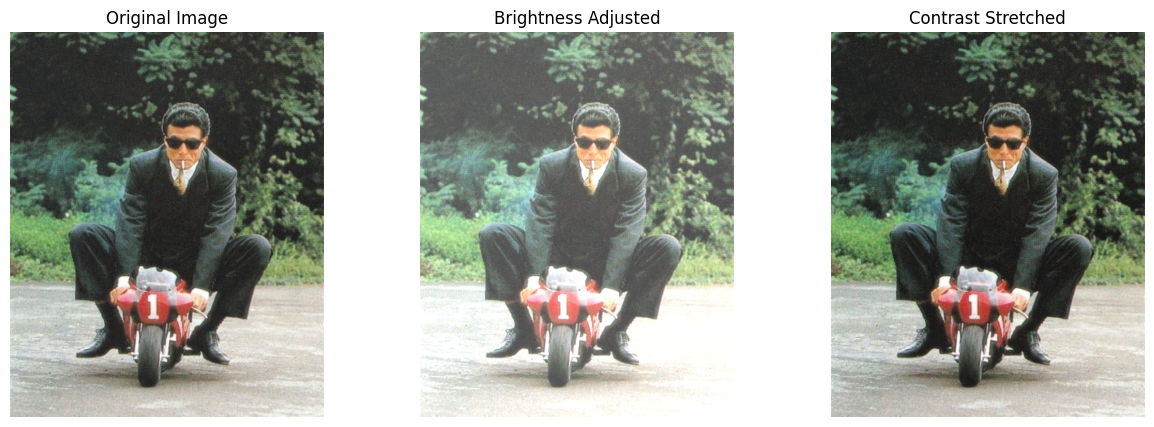

In [2]:
# Brightness adjustment
brightness_adjusted = cv2.convertScaleAbs(image, alpha=1, beta=50)

# Contrast stretching
contrast_stretched = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(brightness_adjusted, cv2.COLOR_BGR2RGB))
axes[1].set_title('Brightness Adjusted')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(contrast_stretched, cv2.COLOR_BGR2RGB))
axes[2].set_title('Contrast Stretched')
axes[2].axis('off')
plt.show()

Brightness adjustment made the entire image lighter by adding a constant value to all pixels, improving visibility in darker regions, while contrast stretching enhanced the distinction between dark and light areas by expanding the intensity range, making image details more pronounced.

## 2.2 Basic Image Filtering: Mean and Gaussian Filtering

Image filtering is used for smoothing, noise reduction, and feature enhancement. Both methods below operate by convolving the image with a kernel (a small matrix):

- **Mean Filtering**: Also known as box filtering or average filtering, replaces each pixel with the average value of its neighboring pixels within a 5x5 window. This is a simple low-pass filter that reduces noise but also blurs edges.

- **Gaussian Filtering**: Uses a weighted average where central pixels have higher weights following a Gaussian distribution. This preserves edges better than mean filtering while still reducing noise. The mathematical basis is the 2D Gaussian function: G(x,y) = (1/(2π𝜎²))e^(-(x²+y²)/(2𝜎²)).

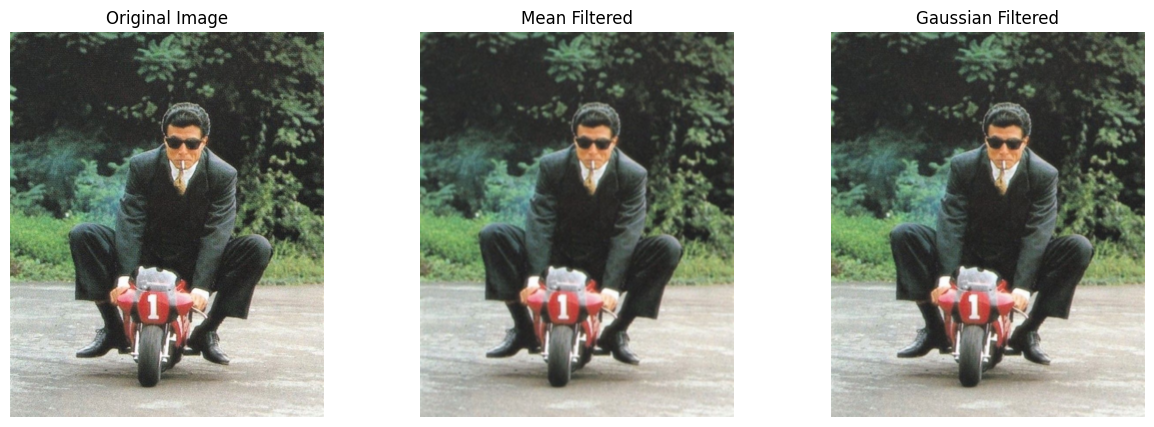

In [3]:
# Mean filtering
mean_filtered = cv2.blur(image, (5, 5))

# Gaussian filtering
gaussian_filtered = cv2.GaussianBlur(image, (5, 5), 0)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(mean_filtered, cv2.COLOR_BGR2RGB))
axes[1].set_title('Mean Filtered')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(gaussian_filtered, cv2.COLOR_BGR2RGB))
axes[2].set_title('Gaussian Filtered')
axes[2].axis('off')
plt.show()

Mean filtering produced a much more blurred image, but we notice the edges were consequently lost due to its averaging sum. 

Gaussian filtering on the other hand provided a more natural smoothing effect that preserved edges better due to its weighted approach that prioritizes central pixels.

## 2.3 Global Thresholding

Thresholding is a segmentation technique that separates objects from the background by converting a grayscale image into a binary image. In global thresholding:

- The image is first converted to grayscale (intensity values from 0 to 255)
- A single threshold value (127 in this case) is applied across the entire image
- Pixels with intensity greater than the threshold are set to white (255), others to black (0)

The mathematical operation is: $g(x,y) = 255$ if $f(x,y) > threshold$, otherwise $g(x,y) = 0$, where $f(x,y)$ is the original pixel value and $g(x,y)$ is the resulting binary pixel value. This technique works best when the image histogram has clear bimodal distribution.

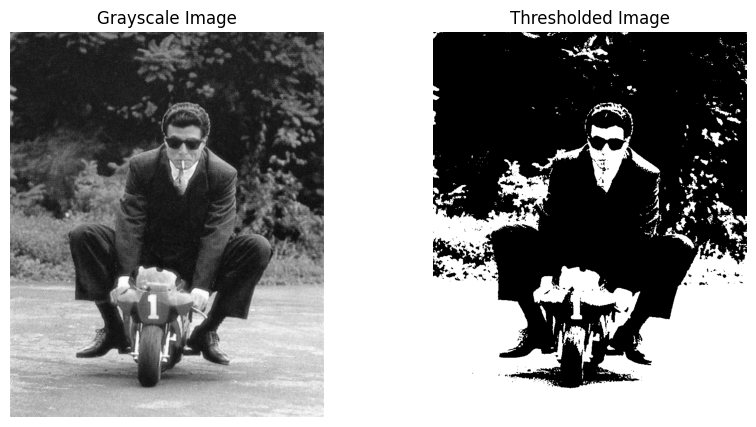

In [ ]:
# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply global thresholding
_, thresholded = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')
axes[1].imshow(thresholded, cmap='gray')
axes[1].set_title('Thresholded Image')
axes[1].axis('off')
plt.show()

## 2.4 Edge Detection: Sobel and Prewitt Operators

Edge detection identifies points in an image where the brightness changes sharply, indicating boundaries between objects. The Sobel operator uses two 3×3 kernels to approximate the derivatives of the image intensity function:

- **Sobel X**: Detects horizontal edges using the kernel [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
- **Sobel Y**: Detects vertical edges using the kernel [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]
- **Sobel Magnitude**: Combines both X and Y gradients using the Euclidean distance formula: √(Gx² + Gy²)

This technique is based on calculating the gradient of image intensity at each pixel, which gives the direction of the largest increase in intensity and the rate of change in that direction.

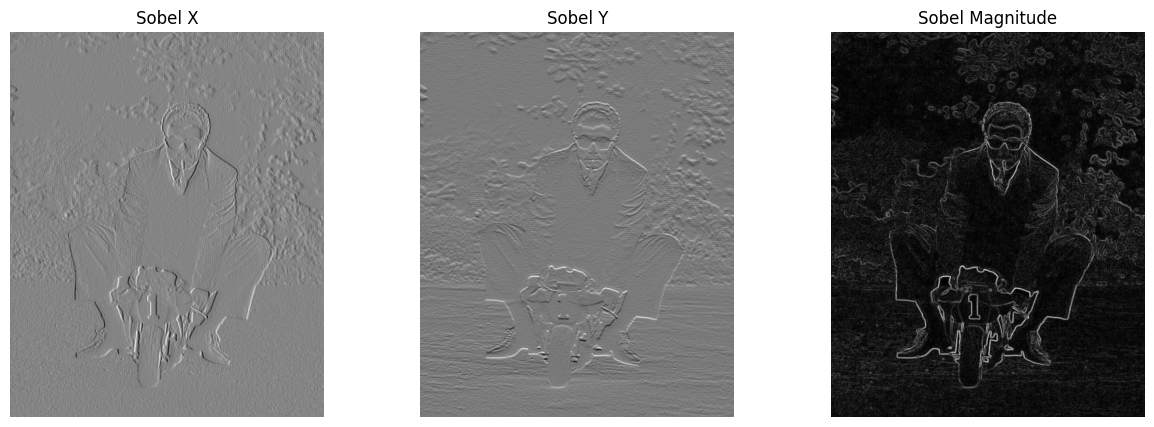

In [5]:
# Sobel edge detection
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_edges = cv2.magnitude(sobel_x, sobel_y)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sobel_x, cmap='gray')
axes[0].set_title('Sobel X')
axes[0].axis('off')
axes[1].imshow(sobel_y, cmap='gray')
axes[1].set_title('Sobel Y')
axes[1].axis('off')
axes[2].imshow(sobel_edges, cmap='gray')
axes[2].set_title('Sobel Magnitude')
axes[2].axis('off')
plt.show()

- Sobel X detected horizontal edges, highlighting vertical structures. 
- Sobel Y detected vertical edges, emphasizing horizontal structures. 
- The Sobel magnitude combined both to create a comprehensive edge map that outlines all significant boundaries in the image, creating a sketch-like representation.

## 2.5 Histogram Equalization

Histogram equalization enhances image contrast by redistributing intensity values to spread more uniformly across the available range. The process works by:

1. Calculating the histogram (frequency distribution of pixel intensities)
2. Computing the cumulative distribution function (CDF) of the histogram
3. Mapping each pixel to a new value based on the normalized CDF

The mathematical transformation is: g(x,y) = round(255 * CDF(f(x,y))), where CDF is the cumulative distribution function of the pixel intensities.

This technique is particularly effective for images with poor contrast due to limited intensity range or predominant brightness/darkness. It doesn't require any parameters and adapts to the specific intensity distribution of each image.

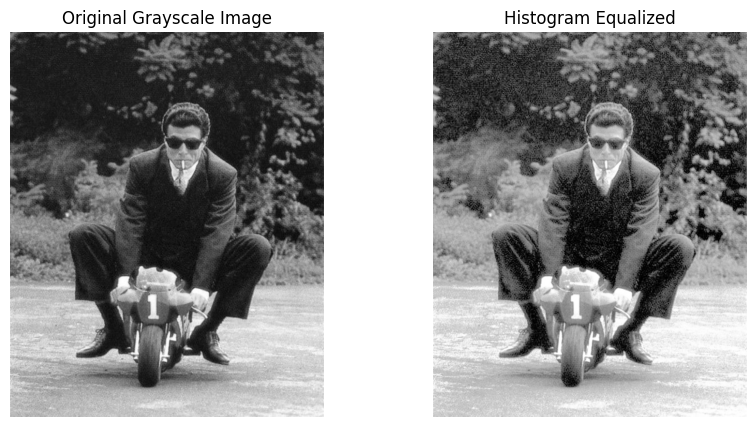

In [6]:
# Apply histogram equalization
equalized = cv2.equalizeHist(gray_image)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')
axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')
plt.show()

Histogram equalization dramatically enhanced contrast by redistributing pixel intensities more uniformly across the available range. 

## 2.6 2D Convolution Operation

Convolution is a core operation in image processing where each pixel is modified based on a weighted sum of its neighbors. The pattern of weights is defined by a kernel (or filter).

In this example, we use a sharpening kernel defined as:
```
[[-1, -1, -1],
 [-1,  9, -1],
 [-1, -1, -1]]
```

This kernel emphasizes the central pixel (value 9) while subtracting the surrounding pixels (value -1), which enhances edges and fine details. The mathematical operation is:

$g(x,y) = ∑∑ f(x-i,y-j) * k(i,j)$

where f is the original image, k is the kernel, and g is the resulting image. The convolution operation is at the heart of many image processing tasks, including filtering, feature extraction, and deep learning-based computer vision.

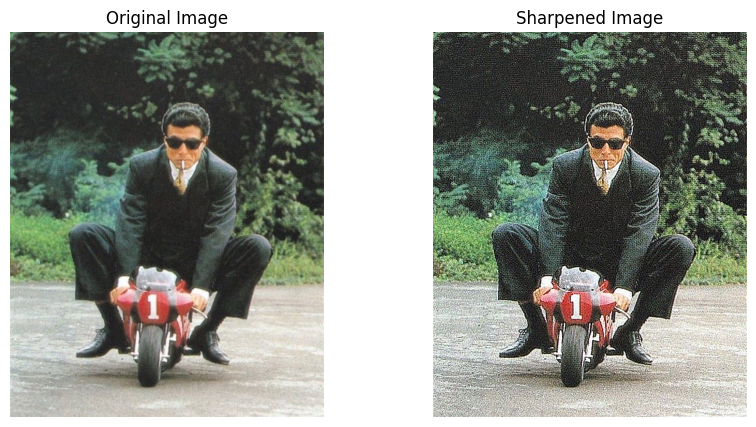

In [7]:
# Define sharpening kernel
kernel = np.array([[-1, -1, -1],
                  [-1,  9, -1],
                  [-1, -1, -1]])

# Apply 2D convolution
sharpened = cv2.filter2D(image, -1, kernel)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
axes[1].set_title('Sharpened Image')
axes[1].axis('off')
plt.show()

The sharpening kernel applied via 2D convolution enhanced fine details and edges by amplifying each pixel relative to its neighbors, which produces a very 'sharp' or rather crisp image.